# Integração Numérica da Distância de Luminosidade pela Métrica de Hogg em Modelos FLRW

Este notebook apresenta a rotina de integração numérica para o cálculo da Distância de Luminosidade ($D_L$) e do Módulo de Distância ($\mu$) baseada na formulação de Hogg para modelos cosmológicos de Friedmann-Lemaître-Robertson-Walker (FLRW).

**Autor:** Victor Moreira Acacio

---

## 1. Fundamentação Teórica e Parâmetros

A evolução da taxa de expansão do universo em função do redshift $z$ é descrita pela função de expansão $E(z)$, que depende dos parâmetros de densidade para a matéria ($\Omega_m$), curvatura ($\Omega_k$) e energia escura ($\Omega_{EE}$), considerando sua equação de estado $w$:

$$E(z) = \sqrt{\Omega_m(1+z)^3 + \Omega_k(1+z)^2 + \Omega_{EE}(1+z)^{3(1+w)}}$$

A partir de $E(z)$, a distância comóvel radial (linha de visada) $D_C$ é obtida através da integração:

$$D_C = \frac{c}{H_0} \int_0^z \frac{dz'}{E(z')}$$

BIBLIOTECAS

In [1]:
from astropy import constants as const
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.integrate import quad
from pathlib import Path as path
from matplotlib.ticker import AutoMinorLocator

PARAMETERS - Parâmetros modificáveis para a simulação

In [2]:
#! -------------------------------------------------- Parâmetros de Entrada --------------------------------------------------
Omega_M = 0.315  # Densidade de matéria [adm.]
Omega_EE = 0.685  # Densidade de energia escura [adm.]
w = -1  # Parâmetro de equação de estado da energia escura [adm.]
z = 10  # Redshift máximo [adm.]


CONSTANTS - Constantes utilizadas dentro do código

In [3]:
#
#! -------------------------------------------------- Bibliotecas --------------------------------------------------
from astropy import constants as const

#! -------------------------------------------------- Constantes Físicas --------------------------------------------------
H0 = 70  # Constante de Hubble [km/s/Mpc]
c = const.c.to("km/s").value  # Velocidade da luz [km/s]
#! -------------------------------------------------- Passo de Output --------------------------------------------------
z_step = 10e-4  # Distância entre um ponto e outro nos outputs gerados


CORE - Núcleo Matemático

In [4]:
#
#! -------------------------------------------------- Bibliotecas --------------------------------------------------
import numpy as np


#! -------------------------------------------------- Funções Fundamentais --------------------------------------------------
def q0(Omega_M, Omega_EE, w):
    """Calcula o parâmetro de desaceleração atual (q0) a partir dos parâmetros de densidade de matéria e energia escura."""
    return 0.5 * Omega_M + 0.5 * Omega_EE * (1 + 3 * w)


def dL(Omega_M, Omega_EE, resint, z):
    """Calcula a distância de luminosidade (dL) a partir da distância comóvel transversal (dm) e do redshift (z)."""
    return (1 + z) * dm(Omega_M, Omega_EE, resint)


def approx_dL(Omega_M, Omega_EE, z):
    """Calcula a aproximação de distância de luminosidade (dL) para pequenos redshifts (z) usando o parâmetro de desaceleração (q0)."""
    return (c / H0) * z * (1 + (1 - q0(Omega_M, Omega_EE, w)) * z / 2)


def Omega_K(Omega_M, Omega_EE):
    """Calcula o parâmetro de curvatura (Omega_K) a partir dos parâmetros de densidade de matéria e energia escura."""
    return 1 - (Omega_M + Omega_EE)


def mu(Omega_M, Omega_EE, resint, z):
    """Calcula a magnitude de distância (mu) a partir da distância de luminosidade (dL) e do redshift (z)."""
    return 5 * np.log10(dL(Omega_M, Omega_EE, resint, z)) + 25


def E(z, Omega_M, Omega_EE):
    """Calcula a função de expansão (E) a partir do redshift (z) e dos parâmetros de densidade de matéria e energia escura."""
    return np.sqrt(
        Omega_M * (1 + z) ** 3
        + Omega_EE * (1 + z) ** (3 * (1 + w))
        + Omega_K(Omega_M, Omega_EE) * (1 + z) ** 2
    )


def Sk(Omega_M, Omega_EE, r):
    """Calcula a função de distância comóvel transversal (Sk) a partir do parâmetro de curvatura (k) e da distância comóvel radial (r)."""
    Ok = Omega_K(Omega_M, Omega_EE)
    DH = c / H0
    if Ok > 0:
        return (DH / np.sqrt(Ok)) * np.sinh(np.sqrt(Ok) * r / DH)
    elif Ok < 0:
        return (DH / np.sqrt(-Ok)) * np.sin(np.sqrt(-Ok) * r / DH)
    else:
        return r


def dm(Omega_M, Omega_EE, resint):
    """Calcula a distância comóvel transversal (dm) a partir do parâmetro de curvatura (k) e da distância comóvel radial (dC)."""
    return Sk(Omega_M, Omega_EE, dC(resint))


def integral(z, Omega_M, Omega_EE):
    """Formaliza a quantidade a ser integrada para o cálculo da distância comóvel radial (dC) a partir do redshift (z) e dos parâmetros de densidade de matéria e energia escura."""
    return 1 / E(z, Omega_M, Omega_EE)


def dC(resint):
    """Calcula o valor de distância comóvel radial (dC) a partir do resultado da integração dda função int."""
    return (c / H0) * resint


def UniType(Omega_k):
    """Determina o tipo de universo estudado baseado no valor do Parâmetro de Densidade de Curvatura(Omega_k)"""
    if Omega_k > 0:
        return "Universo Aberto"
    elif Omega_k < 0:
        return "Universo Fechado"
    else:
        return "Universo Plano"


def k(Omega_M, Omega_EE):
    """Determina o parâmetro de curvatura com base no valor do Parâmetro de Densidade de Curvatura (Omega_k)"""
    Ok = Omega_K(Omega_M, Omega_EE)
    if Ok > 0:
        return -1
    elif Ok < 0:
        return +1
    else:
        return 0


PLOT - Relações de plotagem

In [5]:
#
#! -------------------------------------------------- Bibliotecas --------------------------------------------------
import matplotlib.pyplot as plt
import random
from pathlib import Path as path
from matplotlib.ticker import AutoMinorLocator


#! -------------------------------------------------- Funções de Plotagem de Gráficos --------------------------------------------------
def plot(
    save, x, y, titulo="", titulo_x="X", titulo_y="Y", tam_fonte=14, espessura=1.5
):
    # 1. Configurações globais para mimetizar o padrão LaTeX/Científico
    plt.rcParams.update(
        {
            "font.family": "serif",  # Fonte com serifa
            "mathtext.fontset": "dejavuserif",  # Fórmulas matemáticas no estilo serif
            "axes.labelsize": tam_fonte,
            "font.size": tam_fonte,
            "xtick.labelsize": tam_fonte - 2,
            "ytick.labelsize": tam_fonte - 2,
            "axes.linewidth": 1.2,  # Bordas da caixa mais firmes
        }
    )
    fig, ax = plt.subplots(
        figsize=(8, 6), dpi=100
    )  # dpi=100 apenas para visualização na tela
    # 2. Plotagem da linha (cores sólidas e clássicas funcionam melhor em artigos)
    ax.plot(x, y, linewidth=espessura, color="black", linestyle="-")
    # 3. Textos (Títulos não são comuns dentro de gráficos de artigos, usa-se a legenda do LaTeX,
    # mas mantive a funcionalidade caso precise para apresentações)
    if titulo != "":
        ax.set_title(titulo, fontsize=tam_fonte + 2, pad=15)

    ax.set_xlabel(titulo_x, labelpad=8)
    ax.set_ylabel(titulo_y, labelpad=8)
    # 4. Configuração dos Ticks (Para dentro, em todos os lados)
    ax.tick_params(
        which="major", direction="in", length=6, width=1.2, top=True, right=True
    )
    ax.tick_params(
        which="minor", direction="in", length=3, width=1.0, top=True, right=True
    )

    # Adicionando subdivisões (minor ticks) automaticamente
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    # 5. Fechando a caixa do gráfico (Spines visíveis e em preto)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
    # Grids geralmente são desativados em física, mantendo o fundo limpo.
    ax.grid(False)
    plt.tight_layout()
    # 6. Salvamento em altíssima resolução
    if save == True:
        if titulo == "":
            titulo = f"graph{random.randint(0,100000)}"

        folderData = path("figures")
        folderData.mkdir(parents=True, exist_ok=True)

        # dpi=600 é o exigido por grande parte das revistas científicas para gráficos em vetor/linha
        plt.savefig(
            folderData / f"{titulo.replace(' ', '')}.png",
            bbox_inches="tight",
            dpi=600,
            facecolor="white",  # Garante que o fundo não fique transparente
            transparent=False,
        )
    plt.show()


def ppplot(
    save,
    x1,
    y1,
    x2,
    y2,
    x3,
    y3,
    label1="Modelo1",
    label2="Modelo2",
    label3="Modelo3",
    titulo="",
    titulo_x="X",
    titulo_y="Y",
    tam_fonte=14,
    espessura=1.5,
):
    # 1. Configurações globais para padrão LaTeX/Científico
    plt.rcParams.update(
        {
            "font.family": "serif",
            "mathtext.fontset": "dejavuserif",
            "axes.labelsize": tam_fonte,
            "font.size": tam_fonte,
            "xtick.labelsize": tam_fonte - 2,
            "ytick.labelsize": tam_fonte - 2,
            "axes.linewidth": 1.2,
        }
    )
    fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
    # 2. Plotagem das curvas
    # Cores clássicas e estilos de linha distintos garantem leitura perfeita em preto e branco
    ax.plot(x1, y1, linewidth=espessura, color="black", linestyle="-", label=label1)
    ax.plot(x2, y2, linewidth=espessura, color="blue", linestyle="--", label=label2)
    ax.plot(x3, y3, linewidth=espessura, color="red", linestyle=":", label=label3)
    # 3. Títulos e Eixos
    if titulo != "":
        ax.set_title(titulo, fontsize=tam_fonte + 2, pad=15)
    ax.set_xlabel(titulo_x, labelpad=8)
    ax.set_ylabel(titulo_y, labelpad=8)
    # 4. Configuração dos Ticks (Para dentro, em todos os lados)
    ax.tick_params(
        which="major", direction="in", length=6, width=1.2, top=True, right=True
    )
    ax.tick_params(
        which="minor", direction="in", length=3, width=1.0, top=True, right=True
    )
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    # 5. Fechando a caixa do gráfico
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
    ax.grid(False)  # Mantendo fundo limpo
    # 6. Legenda profissional (Sem sombra, cantos retos, borda preta)
    ax.legend(
        fontsize=tam_fonte - 2,
        frameon=True,
        fancybox=False,  # Desativa os cantos arredondados
        shadow=False,  # Desativa a sombra (incomum em artigos)
        edgecolor="black",  # Borda sólida
        loc="best",
    )
    plt.tight_layout()
    # 7. Salvamento em alta resolução
    if save == True:
        if titulo == "":
            titulo = f"graph{random.randint(0,100000)}"

        folderData = path("figures")
        folderData.mkdir(parents=True, exist_ok=True)

        plt.savefig(
            folderData / f"{titulo.replace(' ','')}.png",
            bbox_inches="tight",
            dpi=600,
            facecolor="white",
            transparent=False,
        )
    plt.show()


SAVES E LOAD - Relações de salvamento e leitura de arquivos na máquina

In [6]:
#
#! -------------------------------------------------- Bibliotecas --------------------------------------------------
import numpy as np
from pathlib import Path as path


#! -------------------------------------------------- Funções de Salvamento .txt --------------------------------------------------
def save_data(
    nome_arquivo="data",
    decimais=10,
    vecX=[],
    vecY=[],
    description="",
    dominio_inferior=0.0,
    dominio_superior=0.0,
    x_grand="",
    x_unit="",
    y_grand="",
    y_unit="",
):  # Função que salva um determinado conjunto de dados em um arquivo.txt
    data = np.column_stack((vecX, vecY))
    header_text = (
        f"Descripiton: {description}\n"
        f"Domain: {x_grand} in [{dominio_inferior}, {dominio_superior}]\n"
        f"Units: {x_grand} [{x_unit}], {y_grand} [{y_unit}] \n"
        f"{x_grand},{y_grand}"
    )
    folderData = path("data")
    folderData.mkdir(parents=True, exist_ok=True)
    np.savetxt(
        f"{folderData}/{nome_arquivo}.txt",
        data,
        fmt=f"%.{decimais}f",
        delimiter=",",
        header=header_text,
        comments="# ",
    )


def load_data(caminho_arquivo):
    """
    Lê um arquivo .txt formatado com cabeçalhos '#' e separado por vírgulas.
    Retorna dois vetores (vetor X e vetor Y).
    """
    try:  # Carrega um documento .txt e cria dois vetores para ele no formato ([0=x,[1]=y)
        vetor_x, vetor_y = np.loadtxt(caminho_arquivo, delimiter=",", unpack=True)
        return vetor_x, vetor_y
    except FileNotFoundError:  # Except apra caso o caminho não seja encontrado
        print(f"Erro: O arquivo '{caminho_arquivo}' não foi encontrado.")
        return [], []
    except Exception as e:  # Except para outros casos de falha
        print(f"Erro ao ler o arquivo: {e}")
        return [], []


MAIN - Simula o modelo FLRW

In [7]:
#
#! -------------------------------------------------- Bibliotecas --------------------------------------------------
import numpy as np
from scipy.integrate import quad


#! -------------------------------------------------- Integração --------------------------------------------------
def main(Omega_M, Omega_EE, w, z, z_step, type="custom"):
    print("-" * 100)
    print("\n Inicializando rotina...  \n")
    print("-" * 100)
    try:  # * Rotina para realizar a integração numérica e calcular os parâmetros associados
        IntANDError = quad(integral, 0, z, args=(Omega_M, Omega_EE))
        resint = IntANDError[0]
        ERRORresint = IntANDError[1]
        print(
            f"Processo de integração numérica finalizado com sucesso!\nResultado da integração: {resint} \nErro estimado: {ERRORresint}"
        )
    except Exception as e:
        print(f"Processo de integração numérica falhou! Erro: {e}")
    print("-" * 100)
    print(
        "\n Cálculando dados...  \n"
    )  # * Devolução dos dados característicos principais para o usuário
    print("-" * 100)
    print(f"Parâmetro derivado de curvatura (Omega_K): {Omega_K(Omega_M, Omega_EE)}")
    print(
        f"Tipo de Universo: {UniType(Omega_K(Omega_M,Omega_EE))}, k = {k(Omega_M, Omega_EE)}"
    )
    print(f"Distância comóvel radial (dC): {dC(resint)} Mpc")
    print(f"Parâmetro de desaceleração (q0): {q0(Omega_M, Omega_EE,w)}")

    #! -------------------------------------------------- Exportação de Dados --------------------------------------------------
    print("-" * 100)
    print("\n Iniciando exportação de dados...  \n")
    print("-" * 100)
    try:  # * Rotina para salvar os dados em arquivos .txt e variáveis vetores
        DLvectorX = []
        DLvectorY = []
        MUvectorX = []
        MUvectorY = []
        DLAPvectorX = []
        DLAPvectorY = []
        DIFvectorX = []
        DIFvectorY = []
        iter = 0
        for i in np.arange(float(z_step), float(z) + float(z_step), float(z_step)):
            resint = quad(integral, 0, i, args=(Omega_M, Omega_EE))[0]
            DLvectorX.append(i)
            DLvectorY.append(dL(Omega_M, Omega_EE, resint, i))
            MUvectorX.append(i)
            MUvectorY.append(mu(Omega_M, Omega_EE, resint, i))
            DLAPvectorX.append(i)
            DLAPvectorY.append(approx_dL(Omega_M, Omega_EE, i))
        for y in DLvectorY:
            DIFvectorY.append(y - DLAPvectorY[iter])
            iter = iter + 1
        DIFvectorX = DLvectorX
        if type == "custom":
            save_data(
                f"DLdados",
                10,
                DLvectorX,
                DLvectorY,
                "Distribuicao de Distancia de Luminosidade",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"MUdados",
                10,
                MUvectorX,
                MUvectorY,
                "Distribuicao de Modulo de Distancia",
                0,
                10,
                "z",
                "adm.",
                "mu",
                "mag",
            )
            save_data(
                f"DLAPdados",
                10,
                DLAPvectorX,
                DLAPvectorY,
                "Distribuicao de Distancia de Luminosidade Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"DIFdados",
                10,
                DIFvectorX,
                DIFvectorY,
                "Analise de Erro na Distribuicao de Distancia de Luminosidade exata e Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
        elif type == "M":
            save_data(
                f"DLdadosM",
                10,
                DLvectorX,
                DLvectorY,
                "Distribuicao de Distancia de Luminosidade",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"MUdadosM",
                10,
                MUvectorX,
                MUvectorY,
                "Distribuicao de Modulo de Distancia",
                0,
                10,
                "z",
                "adm.",
                "mu",
                "mag",
            )
            save_data(
                f"DLAPdadosM",
                10,
                DLAPvectorX,
                DLAPvectorY,
                "Distribuicao de Distancia de Luminosidade Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"DIFdadosM",
                10,
                DIFvectorX,
                DIFvectorY,
                "Analise de Erro na Distribuicao de Distancia de Luminosidade exata e Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
        elif type == "EE":
            save_data(
                f"DLdadosEE",
                10,
                DLvectorX,
                DLvectorY,
                "Distribuicao de Distancia de Luminosidade",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"MUdadosEE",
                10,
                MUvectorX,
                MUvectorY,
                "Distribuicao de Modulo de Distancia",
                0,
                10,
                "z",
                "adm.",
                "mu",
                "mag",
            )
            save_data(
                f"DLAPdadosEE",
                10,
                DLAPvectorX,
                DLAPvectorY,
                "Distribuicao de Distancia de Luminosidade Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"DIFdadosEE",
                10,
                DIFvectorX,
                DIFvectorY,
                "Analise de Erro na Distribuicao de Distancia de Luminosidade exata e Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
        print("Exportação de dados concluida com sucesso!")
    except Exception as e:
        print(f"Falha no processo de salvamento! Erro: {e}")


if __name__ == "__main__":
    main(Omega_M, Omega_EE, w, z, z_step, type="custom")


----------------------------------------------------------------------------------------------------

 Inicializando rotina...  

----------------------------------------------------------------------------------------------------
Processo de integração numérica finalizado com sucesso!
Resultado da integração: 2.1658774268377683 
Erro estimado: 1.867051910489849e-12
----------------------------------------------------------------------------------------------------

 Cálculando dados...  

----------------------------------------------------------------------------------------------------
Parâmetro derivado de curvatura (Omega_K): 0.0
Tipo de Universo: Universo Plano, k = 0
Distância comóvel radial (dC): 9275.910250262996 Mpc
Parâmetro de desaceleração (q0): -0.5275000000000001
----------------------------------------------------------------------------------------------------

 Iniciando exportação de dados...  

------------------------------------------------------------------------

BASIC_PLOTS - Plots do Universo simulado customizado em parâmetros

----------------------------------------------------------------------------------------------------

 Criando gráficos...  

----------------------------------------------------------------------------------------------------


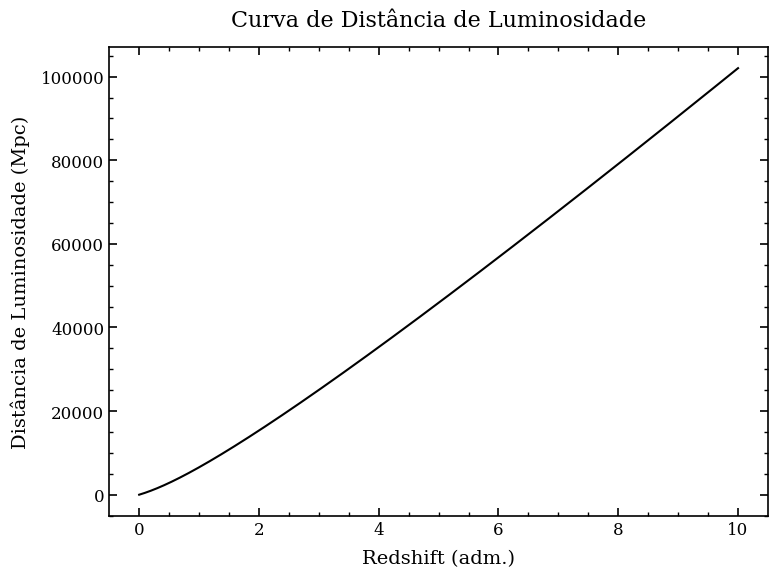

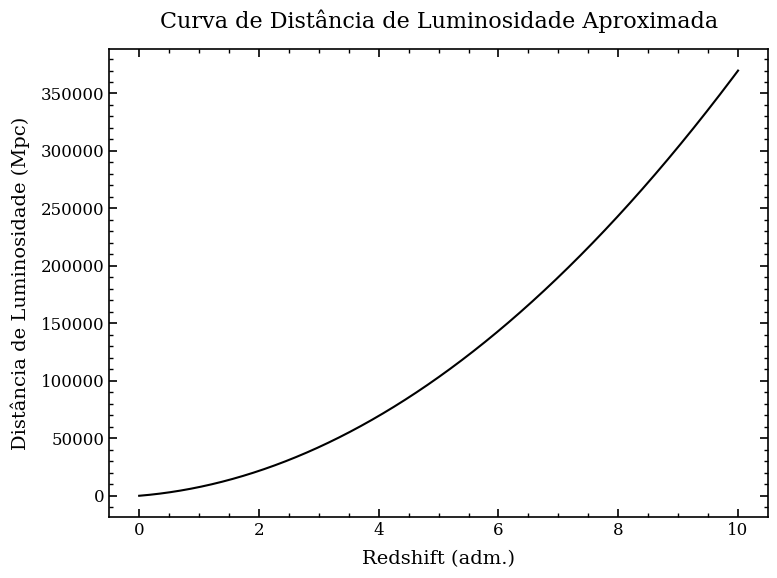

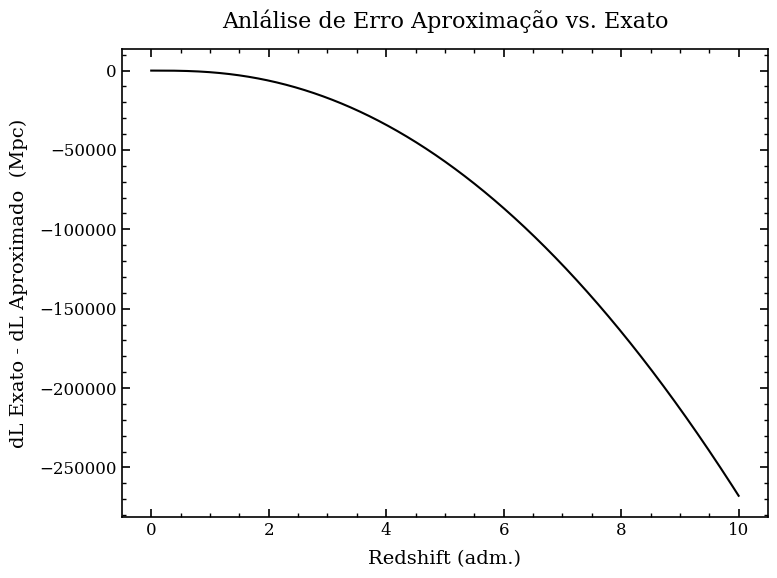

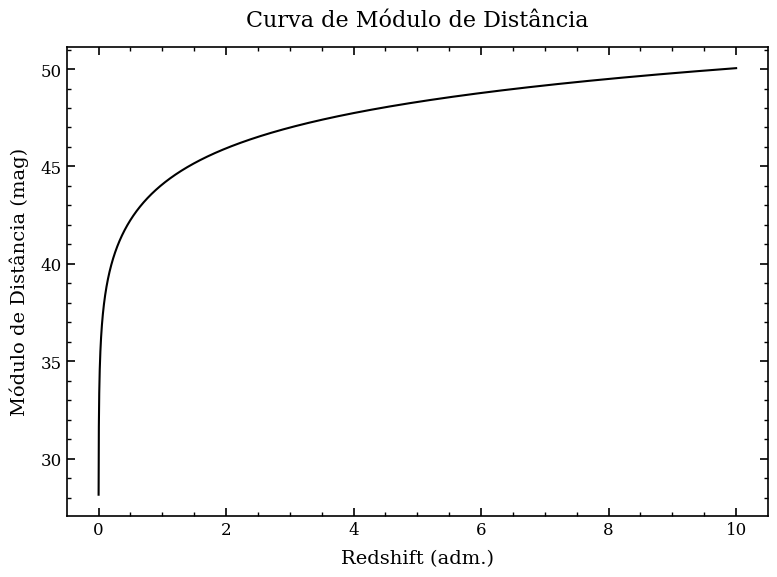

Criação e salvamento dos gráficos concluida com sucesso!


In [8]:
#! -------------------------------------------------- Lendo, Criando e Salvando Gráficos --------------------------------------------------
print("-" * 100)
print("\n Criando gráficos...  \n")
print("-" * 100)
try:  # * Rotina para plotagem dos gráficos
    DLvectorX = load_data(f"data/DLdados.txt")[0]
    DLAPvectorX = load_data(f"data/DLAPdados.txt")[0]
    DIFvectorX = load_data(f"data/DIFdados.txt")[0]
    MUvectorX = load_data(f"data/MUdados.txt")[0]
    DLvectorY = load_data(f"data/DLdados.txt")[1]
    DLAPvectorY = load_data(f"data/DLAPdados.txt")[1]
    DIFvectorY = load_data(f"data/DIFdados.txt")[1]
    MUvectorY = load_data(f"data/MUdados.txt")[1]
    plot(
        True,
        DLvectorX,
        DLvectorY,
        f"Curva de Distância de Luminosidade",
        "Redshift (adm.)",
        "Distância de Luminosidade (Mpc)",
    )
    plot(
        True,
        DLAPvectorX,
        DLAPvectorY,
        f"Curva de Distância de Luminosidade Aproximada",
        "Redshift (adm.)",
        "Distância de Luminosidade (Mpc)",
    )
    plot(
        True,
        DIFvectorX,
        DIFvectorY,
        f"Anlálise de Erro Aproximação vs. Exato",
        "Redshift (adm.)",
        "dL Exato - dL Aproximado  (Mpc)",
    )
    plot(
        True,
        MUvectorX,
        MUvectorY,
        f"Curva de Módulo de Distância",
        "Redshift (adm.)",
        "Módulo de Distância (mag)",
    )
    print("Criação e salvamento dos gráficos concluida com sucesso!")
except Exception as e:
    print(f"Falha no processo de plotagem dos gráficos! Erro: {e}")


COMPARISON_PLOT - Plots de comparação do universo customizado com universos característicos

----------------------------------------------------------------------------------------------------

 Inicializando rotina...  

----------------------------------------------------------------------------------------------------
Processo de integração numérica finalizado com sucesso!
Resultado da integração: 2.1658774268377683 
Erro estimado: 1.867051910489849e-12
----------------------------------------------------------------------------------------------------

 Cálculando dados...  

----------------------------------------------------------------------------------------------------
Parâmetro derivado de curvatura (Omega_K): 0.0
Tipo de Universo: Universo Plano, k = 0
Distância comóvel radial (dC): 9275.910250262996 Mpc
Parâmetro de desaceleração (q0): -0.5275000000000001
----------------------------------------------------------------------------------------------------

 Iniciando exportação de dados...  

------------------------------------------------------------------------

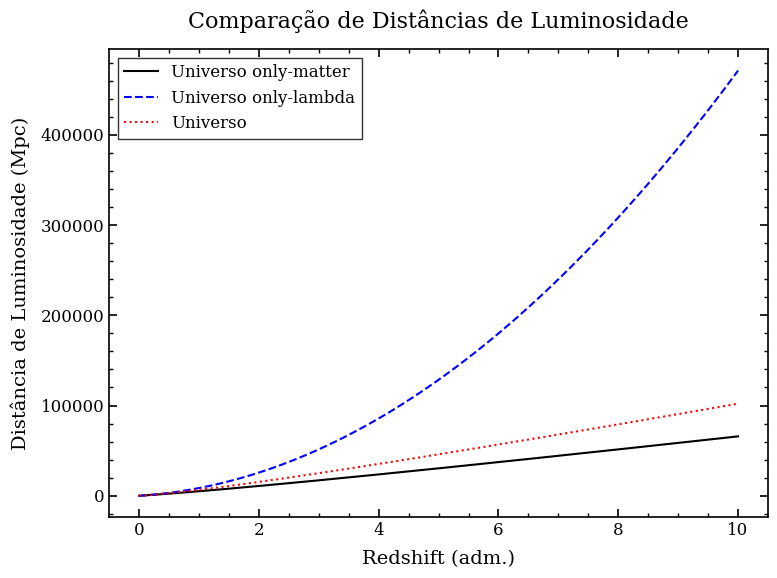

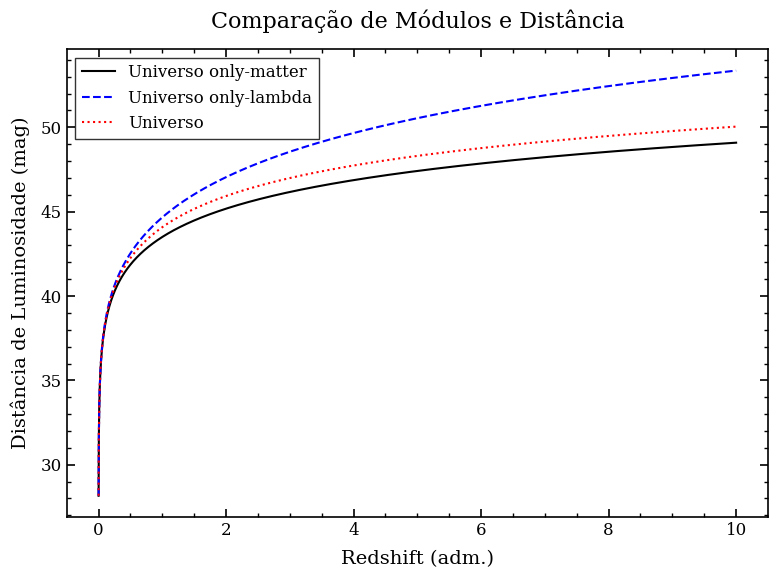

In [9]:
#! -------------------------------------------------- Inicia Rotina de Superposição --------------------------------------------------
try:  # * Inicia a rotina principal para 3 universos diferentes
    main(Omega_M, Omega_EE, w, z, z_step, "custom")
    main(1, 0, -1, z, z_step, "M")
    main(0, 1, -1, z, z_step, "EE")
except Exception as e:
    print(f"Um erro foi encontrado ao tentar executar a rotina principal. Erro: {e}")
try:  # * Inicia processo de plotagem dos gráficos de Distância de Luminosidade
    dadosM = "DLdadosM.txt"
    dadosEE = "DLdadosEE.txt"
    dadosMEE = f"DLdados.txt"
    x1 = load_data(f"data/DLdadosM.txt")[0]
    x2 = load_data(f"data/DLdadosEE.txt")[0]
    x3 = load_data(f"data/DLdados.txt")[0]
    y1 = load_data(f"data/DLdadosM.txt")[1]
    y2 = load_data(f"data/DLdadosEE.txt")[1]
    y3 = load_data(f"data/DLdados.txt")[1]
    ppplot(
        True,
        x1,
        y1,
        x2,
        y2,
        x3,
        y3,
        "Universo only-matter",
        "Universo only-lambda",
        "Universo",
        "Comparação de Distâncias de Luminosidade",
        "Redshift (adm.)",
        "Distância de Luminosidade (Mpc)",
    )
except Exception as e:
    print(
        f"Um erro foi encontrado ao tentar fazer a sobreposição dos gráficos de Distância de luminosidade. Erro: {e}"
    )
try:
    dadosM = "MUdadosM.txt"
    dadosEE = "MUdadosEE.txt"
    dadosMEE = f"MUdados.txt"
    x1 = load_data(f"data/MUdadosM.txt")[0]
    x2 = load_data(f"data/MUdadosEE.txt")[0]
    x3 = load_data(f"data/MUdados.txt")[0]
    y1 = load_data(f"data/MUdadosM.txt")[1]
    y2 = load_data(f"data/MUdadosEE.txt")[1]
    y3 = load_data(f"data/MUdados.txt")[1]
    ppplot(
        True,
        x1,
        y1,
        x2,
        y2,
        x3,
        y3,
        "Universo only-matter",
        "Universo only-lambda",
        "Universo",
        "Comparação de Módulos e Distância",
        "Redshift (adm.)",
        "Distância de Luminosidade (mag)",
    )
except Exception as e:
    print(
        f"Um erro foi encontrado ao tentar fazer a sobreposição dos gráficos de Módulo de Distância. Erro: {e}"
    )
